In [1]:
!uv pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.5/112.6 GB disk)


In [2]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
from IPython.display import display
from google.colab import files
import os, glob

print("✅ Imports ready")

✅ Imports ready


In [3]:
from ultralytics import YOLO
import cv2
import numpy as np
from PIL import Image
from IPython.display import display
from google.colab import files
import os, glob

print("✅ Imports ready")

✅ Imports ready


In [4]:
model = YOLO("yolo26n.pt")
# model = YOLO("yolo26s.pt")  # more accurate, ~2x slower

results = model.train(
    data="construction-ppe.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,
    save=True,
    plots=True,
    name="ppe_train",
)

print(f"\n✅ Training complete. Best model: {model.trainer.best}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=construction-ppe.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ppe_train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0,

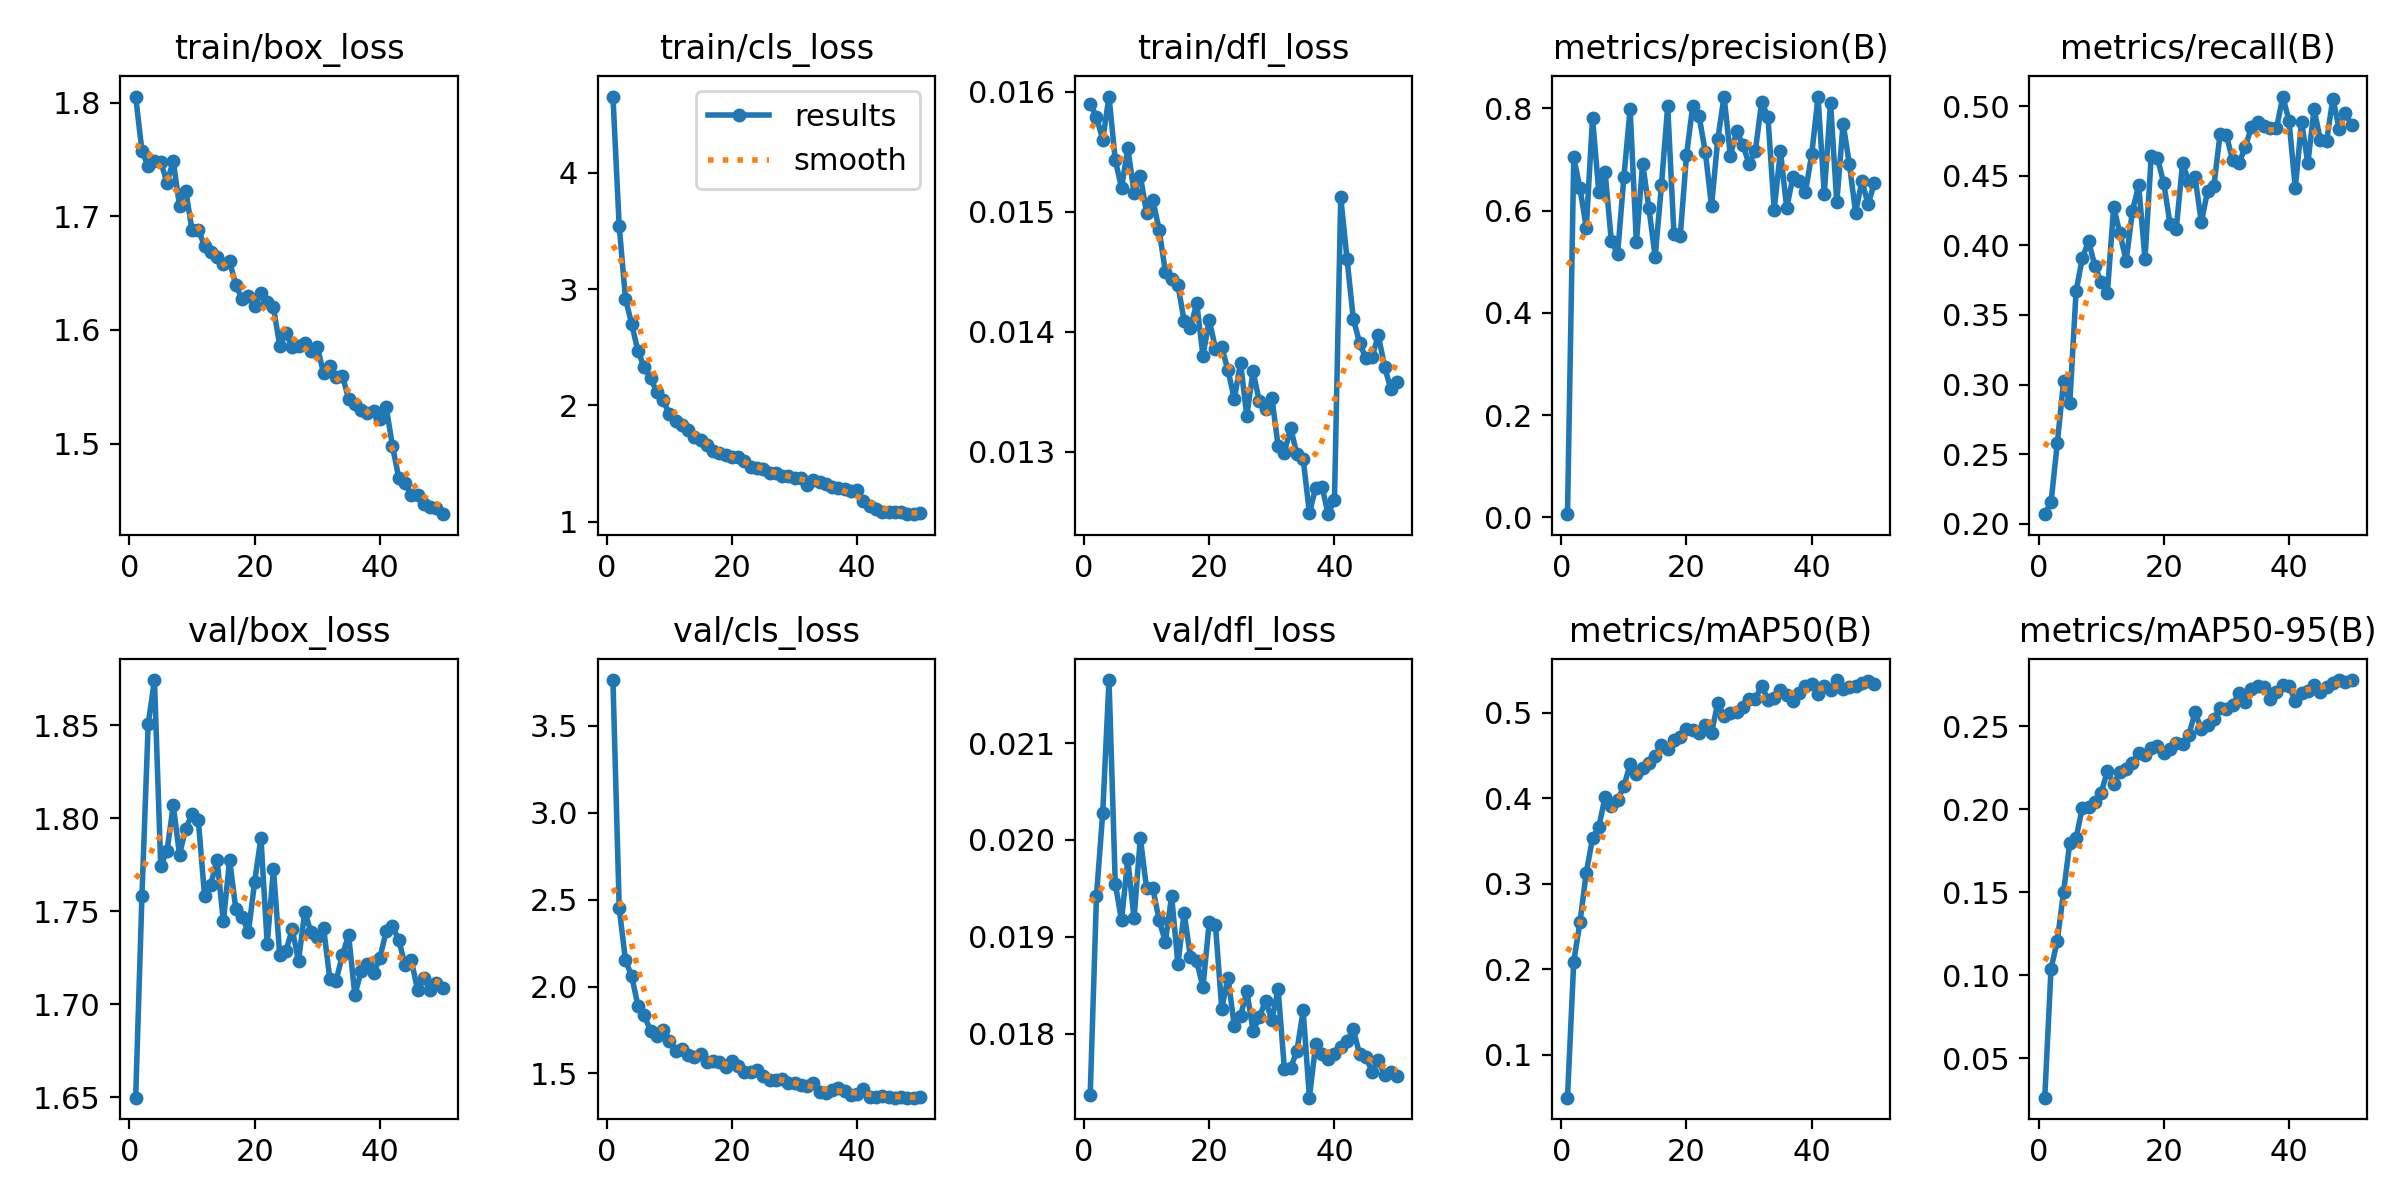

In [5]:
results_img = f"{model.trainer.save_dir}/results.png"
if os.path.exists(results_img):
    img = Image.open(results_img)
    display(img)
else:
    print("No results.png found yet — run training first.")

In [6]:
best_weights = f"{model.trainer.save_dir}/weights/best.pt"
detector = YOLO(best_weights)

CLASS_NAMES = {
    0: "helmet",    1: "gloves",    2: "vest",
    3: "boots",     4: "goggles",   5: "none",
    6: "Person",    7: "no_helmet", 8: "no_goggle",
    9: "no_gloves", 10: "no_boots"
}

# BGR colors — green for PPE present, red for missing
CLASS_COLORS = {
    0:  (0, 220, 100),   # helmet    → green
    1:  (0, 200, 255),   # gloves    → cyan
    2:  (0, 140, 255),   # vest      → orange
    3:  (200, 180, 0),   # boots     → teal
    4:  (180, 80, 255),  # goggles   → purple
    5:  (120, 120, 120), # none      → grey
    6:  (255, 255, 255), # Person    → white
    7:  (0, 0, 220),     # no_helmet → red
    8:  (0, 50, 200),    # no_goggle → red
    9:  (0, 80, 210),    # no_gloves → red
    10: (0, 60, 180),    # no_boots  → red
}

PPE_PRESENT = {0, 1, 2, 3, 4}
PPE_MISSING = {7, 8, 9, 10}

print(f"✅ Loaded: {best_weights}")

✅ Loaded: /content/runs/detect/ppe_train/weights/best.pt


In [7]:
def draw_ppe_results(image_path, predictions, output_path="ppe_output.jpg"):
    img = cv2.imread(image_path)
    H, W = img.shape[:2]
    scale = max(1.0, W / 800)
    lw = max(2, int(2 * scale))
    fs = max(0.45, 0.5 * scale)
    ft = max(1, int(1.5 * scale))
    cs = max(10, int(12 * scale))

    detected_classes = set()

    for box in predictions[0].boxes:
        cls_id          = int(box.cls[0])
        conf            = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        color           = CLASS_COLORS.get(cls_id, (200, 200, 200))
        label           = f"{CLASS_NAMES.get(cls_id, str(cls_id))}  {conf:.0%}"
        detected_classes.add(cls_id)

        # Main box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, lw)

        # Corner brackets
        corners = [
            [(x1, y1+cs), (x1, y1), (x1+cs, y1)],
            [(x2-cs, y1), (x2, y1), (x2, y1+cs)],
            [(x1, y2-cs), (x1, y2), (x1+cs, y2)],
            [(x2-cs, y2), (x2, y2), (x2, y2-cs)],
        ]
        for pts in corners:
            for i in range(len(pts)-1):
                cv2.line(img, pts[i], pts[i+1], color, lw*2)

        # Label pill
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, fs, ft)
        pad    = max(4, int(5 * scale))
        pill_y = y1 - th - pad*2 - 3 if y1 > th + pad*2 + 3 else y1 + 3
        cv2.rectangle(img, (x1, pill_y), (x1 + tw + pad*2, pill_y + th + pad*2), color, -1)
        cv2.putText(img, label, (x1 + pad, pill_y + th + pad),
                    cv2.FONT_HERSHEY_SIMPLEX, fs, (20, 20, 20), ft, cv2.LINE_AA)

    cv2.imwrite(output_path, img)
    return img, detected_classes


def show_image(img_bgr, max_width=800):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)
    w, h = pil.size
    if w > max_width:
        pil = pil.resize((max_width, int(h * max_width / w)), Image.LANCZOS)
    display(pil)


print("✅ Helper functions ready")

✅ Helper functions ready


📂 Upload one or more images (JPG, PNG, WEBP)...


Saving pw 2.jpg to pw 2.jpg

🔍 Running detection on: pw 2.jpg

📋 Detections:
  ✅  vest           x1
  ✅  boots          x2
  👤  Person         x1

🖼️  Result (ppe_pw 2.jpg):


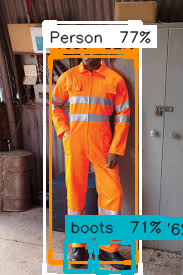

In [8]:
print("📂 Upload one or more images (JPG, PNG, WEBP)...")
uploaded = files.upload()

for fname, fdata in uploaded.items():
    with open(fname, "wb") as f:
        f.write(fdata)

    print(f"\n🔍 Running detection on: {fname}")

    preds = detector.predict(
        source=fname,
        conf=0.25,
        iou=0.45,
        save=False,
        verbose=False,
    )

    out_path = f"ppe_{fname}"
    annotated, found_classes = draw_ppe_results(fname, preds, out_path)

    print("\n📋 Detections:")
    class_counts = {}
    for box in preds[0].boxes:
        cid = int(box.cls[0])
        class_counts[cid] = class_counts.get(cid, 0) + 1

    for cid, count in sorted(class_counts.items()):
        icon = "✅" if cid in PPE_PRESENT else ("❌" if cid in PPE_MISSING else "👤")
        print(f"  {icon}  {CLASS_NAMES[cid]:<14} x{count}")

    if not class_counts:
        print("  ⚠️  No detections above confidence threshold.")

    print(f"\n🖼️  Result ({out_path}):")
    show_image(annotated)

In [9]:
result_files = glob.glob("ppe_*.jpg") + glob.glob("ppe_*.png")
if result_files:
    for f in result_files:
        files.download(f)
        print(f"⬇️  Downloading {f}")
else:
    print("No result files found. Run Cell 7 first.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading ppe_pw 2.jpg


In [10]:
val_results = detector.val(
    data="construction-ppe.yaml",
    split="test",
    conf=0.25,
    iou=0.45,
)

print(f"\n📊 Test mAP50:    {val_results.box.map50:.3f}")
print(f"📊 Test mAP50-95: {val_results.box.map:.3f}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1779.0±756.6 MB/s, size: 99.2 KB)
val: Scanning /content/datasets/construction-ppe/labels/test... 141 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 141/141 2.2Kit/s 0.1s
val: New cache created: /content/datasets/construction-ppe/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 2.5it/s 3.6s
                   all        141       1251      0.555      0.454      0.524      0.298
                helmet        110        192      0.861       0.87      0.918      0.563
                gloves         75        163      0.733      0.675      0.743      0.404
                  vest        111        178      0.797      0.815      0.855      0.573
                 boots         75        211      0.732      0.659      0.737      0.425
               goggles         51         52

📂 Upload a video file (MP4, AVI, MOV)...


Saving video1.avi to video1.avi

📹 Video uploaded: video1.avi
📹 Video info: 640x480  |  30.0 FPS  |  2189 frames
⚙️  Processing (only saving frames with PPE detections)...

  Frame 100/2189  |  kept: 0
  Frame 200/2189  |  kept: 40
  Frame 300/2189  |  kept: 127
  Frame 400/2189  |  kept: 163
  Frame 500/2189  |  kept: 164
  Frame 600/2189  |  kept: 219
  Frame 700/2189  |  kept: 302
  Frame 800/2189  |  kept: 335
  Frame 900/2189  |  kept: 377
  Frame 1000/2189  |  kept: 377
  Frame 1100/2189  |  kept: 411
  Frame 1200/2189  |  kept: 455
  Frame 1300/2189  |  kept: 470
  Frame 1400/2189  |  kept: 518
  Frame 1500/2189  |  kept: 554
  Frame 1600/2189  |  kept: 582
  Frame 1700/2189  |  kept: 582
  Frame 1800/2189  |  kept: 627
  Frame 1900/2189  |  kept: 679
  Frame 2000/2189  |  kept: 679
  Frame 2100/2189  |  kept: 740

✅ Done! 754/2189 frames kept.
💾 Saved: ppe_video_result.mp4

📋 Total PPE detections across video:
  ✅  helmet          14 detections
  ✅  gloves          21 detection

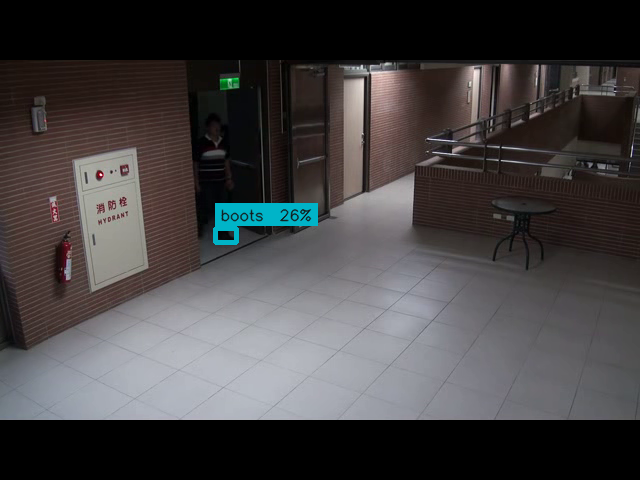

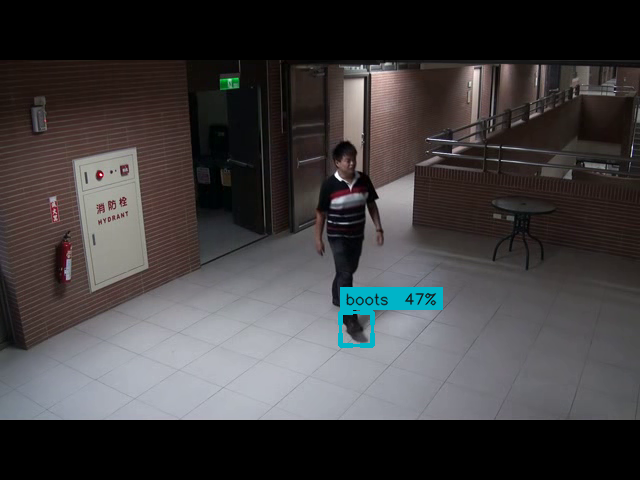

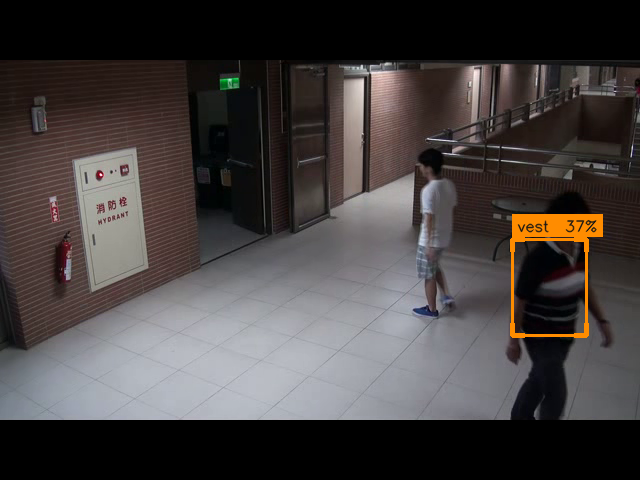

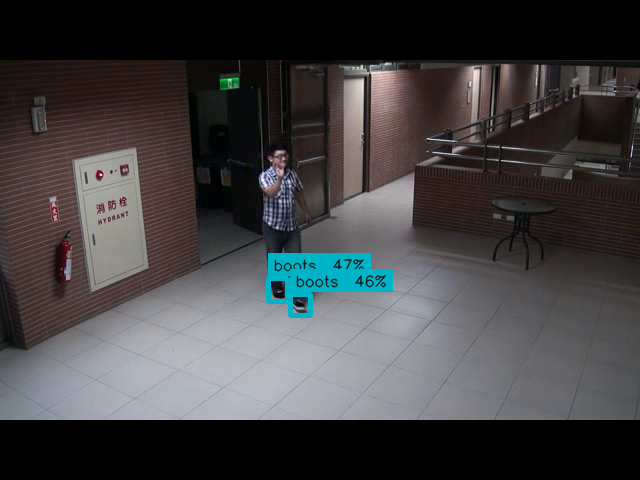

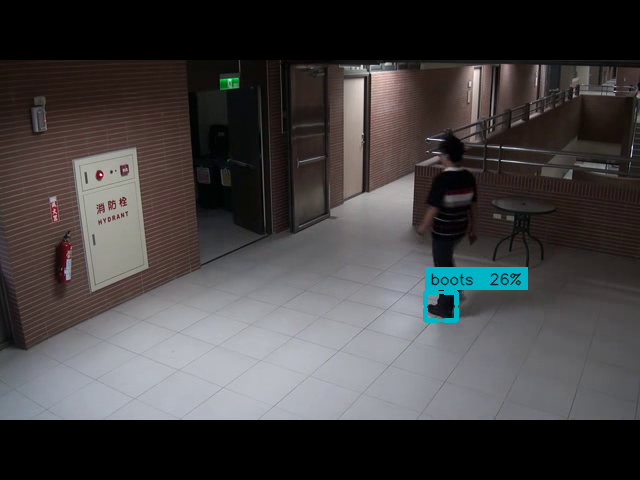

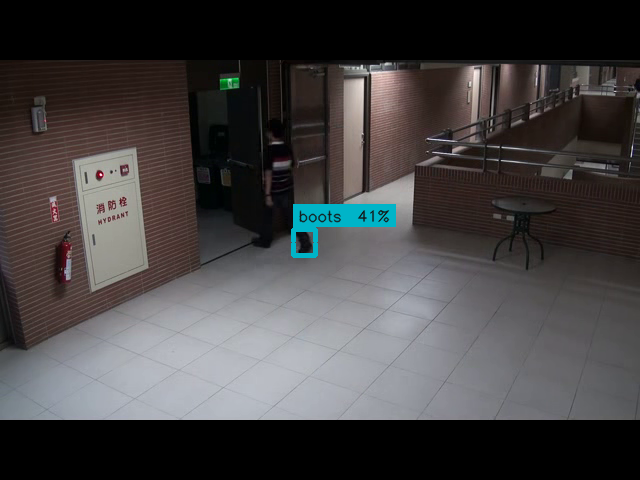

In [15]:
# Only frames containing these PPE classes will be kept
PPE_CLASSES_ONLY = {0, 1, 2, 3, 4, 7, 8, 9, 10}  # helmet, gloves, vest, boots, goggles
# To also keep frames with missing PPE: {0, 1, 2, 3, 4, 7, 8, 9, 10}

def draw_boxes_on_frame(frame, boxes_data):
    H, W = frame.shape[:2]
    scale = max(1.0, W / 800)
    lw = max(2, int(2 * scale))
    fs = max(0.45, 0.5 * scale)
    ft = max(1, int(1.5 * scale))
    cs = max(10, int(12 * scale))

    for cls_id, conf, x1, y1, x2, y2 in boxes_data:
        color = CLASS_COLORS.get(cls_id, (200, 200, 200))
        label = f"{CLASS_NAMES.get(cls_id, str(cls_id))}  {conf:.0%}"

        cv2.rectangle(frame, (x1, y1), (x2, y2), color, lw)

        corners = [
            [(x1, y1+cs), (x1, y1), (x1+cs, y1)],
            [(x2-cs, y1), (x2, y1), (x2, y1+cs)],
            [(x1, y2-cs), (x1, y2), (x1+cs, y2)],
            [(x2-cs, y2), (x2, y2), (x2, y2-cs)],
        ]
        for pts in corners:
            for i in range(len(pts)-1):
                cv2.line(frame, pts[i], pts[i+1], color, lw*2)

        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, fs, ft)
        pad    = max(4, int(5 * scale))
        pill_y = y1 - th - pad*2 - 3 if y1 > th + pad*2 + 3 else y1 + 3
        cv2.rectangle(frame, (x1, pill_y), (x1 + tw + pad*2, pill_y + th + pad*2), color, -1)
        cv2.putText(frame, label, (x1 + pad, pill_y + th + pad),
                    cv2.FONT_HERSHEY_SIMPLEX, fs, (20, 20, 20), ft, cv2.LINE_AA)
    return frame


def process_video(video_path, output_path="ppe_video_result.mp4", conf=0.25, iou=0.45):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("❌ Could not open video file.")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps          = cap.get(cv2.CAP_PROP_FPS) or 25
    W            = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H            = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"📹 Video info: {W}x{H}  |  {fps:.1f} FPS  |  {total_frames} frames")

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    out    = cv2.VideoWriter(output_path, fourcc, fps, (W, H))

    frame_idx        = 0
    kept_frames      = 0
    detection_counts = {}
    preview_frames   = []

    print(f"⚙️  Processing (only saving frames with PPE detections)...\n")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_idx += 1

        preds = detector.predict(
            source=frame,
            conf=conf,
            iou=iou,
            verbose=False,
        )

        boxes_data     = []
        frame_ppe_seen = set()

        for box in preds[0].boxes:
            cls_id = int(box.cls[0])
            if cls_id not in PPE_CLASSES_ONLY:
                continue
            conf_val        = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            boxes_data.append((cls_id, conf_val, x1, y1, x2, y2))
            frame_ppe_seen.add(cls_id)
            detection_counts[cls_id] = detection_counts.get(cls_id, 0) + 1

        if boxes_data:
            annotated = draw_boxes_on_frame(frame.copy(), boxes_data)
            out.write(annotated)
            kept_frames += 1

            if kept_frames % 60 == 1 and len(preview_frames) < 6:
                preview_frames.append(annotated.copy())

        if frame_idx % 100 == 0:
            print(f"  Frame {frame_idx}/{total_frames}  |  kept: {kept_frames}")

    cap.release()
    out.release()

    print(f"\n✅ Done! {kept_frames}/{total_frames} frames kept.")
    print(f"💾 Saved: {output_path}")

    print("\n📋 Total PPE detections across video:")
    for cid, count in sorted(detection_counts.items()):
        print(f"  ✅  {CLASS_NAMES[cid]:<14}  {count} detections")

    if preview_frames:
        print(f"\n🖼️  Sample detected frames:")
        for pf in preview_frames:
            rgb = cv2.cvtColor(pf, cv2.COLOR_BGR2RGB)
            pil = Image.fromarray(rgb)
            w, h = pil.size
            if w > 700:
                pil = pil.resize((700, int(h * 700 / w)), Image.LANCZOS)
            display(pil)

    return output_path


# ── Upload and run ──────────────────────────────────────────────────────────────
print("📂 Upload a video file (MP4, AVI, MOV)...")
uploaded_video = files.upload()

if uploaded_video:
    video_filename = list(uploaded_video.keys())[0]
    with open(video_filename, "wb") as f:
        f.write(uploaded_video[video_filename])
    print(f"\n📹 Video uploaded: {video_filename}")

    output_video = process_video(
        video_path=video_filename,
        output_path="ppe_video_result.mp4",
        conf=0.25,
        iou=0.45,
    )
else:
    print("❌ No video uploaded.")

In [16]:
if os.path.exists("ppe_video_result.mp4"):
    files.download("ppe_video_result.mp4")
    print("⬇️  Download started: ppe_video_result.mp4")
else:
    print("❌ No output video found. Run Cell 12 first.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download started: ppe_video_result.mp4


In [18]:
from ultralytics import YOLO

# Load your trained best.pt
model_to_export = YOLO(f"{model.trainer.save_dir}/weights/best.pt")

model_to_export.export(
    format="engine",   # TensorRT
    half=True,         # FP16 — 2x faster, tiny accuracy drop
    imgsz=640,
    device=0,          # GPU 0 (must export on same GPU you'll run on)
)

engine_path = f"{model.trainer.save_dir}/weights/best.engine"
print(f"✅ Engine saved: {engine_path}")

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,376,981 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/runs/detect/ppe_train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.1 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.87...
ONNX: export success ✅ 1.7s, saved as '/content/runs/detect/ppe_train/weights/best.onnx' (9.4 MB)

TensorRT: starting export with TensorRT 10.15.1.29...
TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 300, 6) DataType.FLOAT
TensorRT: building FP16 engine as /content/runs/detect/ppe_train/weights/best.engine
TensorRT: export success ✅ 161.6s, saved as '/content/runs/detect/ppe_train/weights/best.engine' (7.0 MB)

Export complete (162.0s)
Results saved to /content/runs/detect/ppe_train/weights
Predict:         yolo predict tas

In [19]:
from ultralytics import YOLO

engine_path = f"{model.trainer.save_dir}/weights/best.engine"
engine_model = YOLO(engine_path)

print("✅ TensorRT engine loaded and ready")

✅ TensorRT engine loaded and ready


In [20]:
# Download the engine model
files.download(engine_path)
print(f"⬇️  Downloading engine: {engine_path}")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading engine: /content/runs/detect/ppe_train/weights/best.engine
